In [5]:
%env XLA_PYTHON_CLIENT_PREALLOCATE=False

import pickle
import os
import matplotlib.pyplot as plt
import numpy as np
import jax.numpy as jnp

"""
PKLs = []
PKL_titles = []
DIR = "./output/"
for file in os.listdir(DIR):
    if file.endswith(".pkl") and "merge" not in file:
        PKLs.append(pickle.load(open(DIR+file, "rb")))
        PKL_titles.append(str(file))
n = len(PKLs)"""

idx_per_prefix = dict()
PKLs = []
PKL_titles = []
DIR = "./output_low_memory_10000/"
for idx, file in enumerate(os.listdir(DIR)):
    if file.endswith(".pkl") and "merge" not in file:
        loaded = pickle.load(open(DIR+file, "rb"))
        loaded =  {'res': (None, None, None, loaded['res'][3], None, loaded['res'][5], loaded['res'][6], None, loaded['res'][8]), 'config':loaded['config']}
        idx_per_prefix.update({loaded['config']['prefix']: idx_per_prefix.get(loaded['config']['prefix'], [])+[idx]})
        PKLs.append(loaded)
        PKL_titles.append(str(file))
n = len(PKLs)
plt.rcParams['text.usetex'] = False

env: XLA_PYTHON_CLIENT_PREALLOCATE=False


In [6]:
my_dims = np.array([1, 2, 3, 5, 10, 15, 30, 50, 75, 100]) # 30, 50, 75, 100

idx_per_dim = {}
for prefix in idx_per_prefix:
    idx_per_dim[prefix] = dict()
    for dim in my_dims:
        idx_per_dim[prefix][dim] = [idx for idx in range(n) if PKLs[idx]['config']['dim'] == dim and PKLs[idx]['config']['prefix']==prefix]
temperatures = {}
parameters = {}
critical_temperatures = []
for prefix in idx_per_prefix:
    temperatures[prefix] = dict()
    parameters[prefix] = dict()
    for i, dim in enumerate(my_dims):
        for idx in idx_per_dim[prefix][dim]:
            temperatures[prefix][dim] = np.concatenate([[PKLs[idx]['res'][6][res_dx][jnp.newaxis, :] for res_dx in range(PKLs[idx]['res'][6].shape[0])] for idx in idx_per_dim[prefix][dim]])
            parameters[prefix][dim] = np.concatenate([[PKLs[idx]['res'][3][res_dx].squeeze(axis=-1) for res_dx in range(PKLs[idx]['res'][3].shape[0])] for idx in idx_per_dim[prefix][dim]])
        temperatures[prefix][dim] = temperatures[prefix][dim].reshape((-1, temperatures[prefix][dim].shape[-1]))
        parameters[prefix][dim] = parameters[prefix][dim].reshape((-1, parameters[prefix][dim].shape[-1]))

In [7]:
def last_zero(x):
    return np.where(np.cumsum(x)==0.)[0][-1] if len(np.where(np.cumsum(x)==0.)[0]) else 1

In [8]:
critical_temperatures = dict()
for prefix in idx_per_prefix:
    critical_temperatures[prefix] = np.zeros(shape=(len(my_dims), len(parameters[prefix][1])))
for prefix in idx_per_prefix:
    for idxdim, dim in enumerate(parameters[prefix].keys()):
        number_of_runs = len(parameters[prefix][1])
        if number_of_runs:
            critical_temperatures[prefix][idxdim] = np.array([temperatures[prefix][dim][r][last_zero(parameters[prefix][dim][r])] for r in range(number_of_runs)])

In [22]:
for idx in idx_per_dim[30]:
    if np.any(np.isnan(PKLs[idx]['res'][5])):
        print(idx)

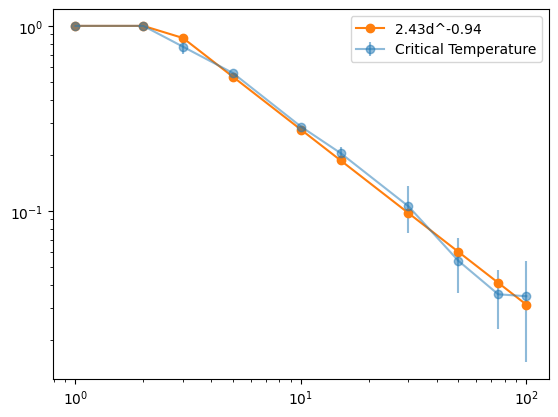

In [23]:
mean_critical_temperatures = critical_temperatures.mean(axis=-1)
log_mean_critical_temperatures = np.log(mean_critical_temperatures)

mask = (log_mean_critical_temperatures < 0)
filtered_log_temperatures = log_mean_critical_temperatures[mask]
filtered_dims = my_dims[mask]
filtered_log_dims = np.log(filtered_dims)
#performing linear regression
import scipy.stats as stats
slope, intercept, r_value, p_value, std_err = stats.linregress(filtered_log_dims, filtered_log_temperatures)
regression_line = np.exp(intercept) * filtered_dims**slope
filled_regression_line = np.concatenate([np.array((len(my_dims)-len(filtered_dims))*[1]), regression_line])

plt.errorbar(my_dims, mean_critical_temperatures, yerr=critical_temperatures.std(axis=-1), marker='o', label='Critical Temperature', alpha=0.5)
plt.loglog(my_dims, filled_regression_line, marker='o', label=rf'{str(np.exp(intercept))[:4]}d^{str(slope)[:5]}')
plt.legend()

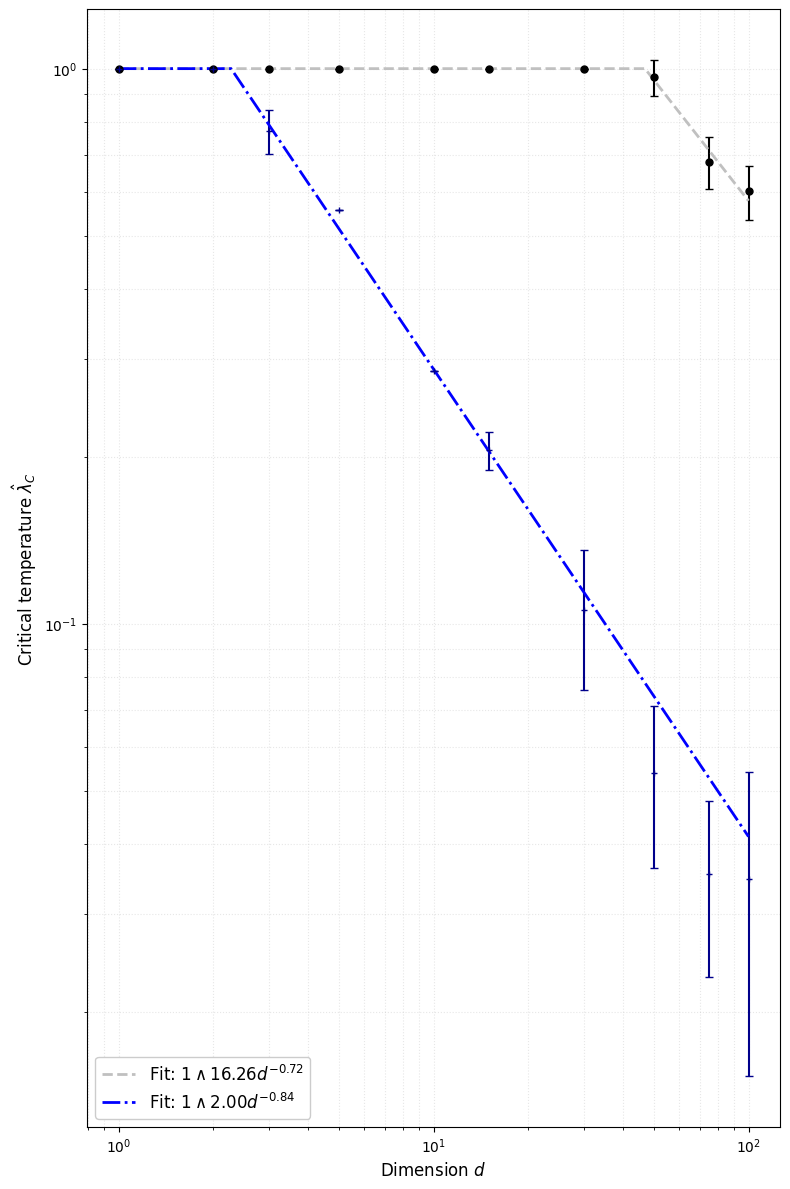

In [23]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import curve_fit

# Setup
fig, ax = plt.subplots(figsize=(8, 12))

# Color scheme
colors = {
    'data': '#505050',  # Dark gray
    'fit': '#D55E00',  # Vermillion (red)
    'active': '#029E73',  # Green (for ρ > 0 region)
    'inactive': '#F5F5F5'  # Light gray (for ρ = 0 region)
}


def make_linear_reg_and_plot(critical_temperatures, color_data=colors['data'], color_fit=colors['fit'], linestyle_reg="--", marker="o", annotate=False):
    mean_critical_temperatures = critical_temperatures.mean(axis=-1)
    log_mean_critical_temperatures = np.log(mean_critical_temperatures)

    # Filter data
    mask = (log_mean_critical_temperatures < 0)
    filtered_log_temperatures = log_mean_critical_temperatures[mask]
    filtered_dims = my_dims[mask]

    # Define power law function
    def power_law(x, a, b):
        return a * (x ** b)

    # Fit power law directly
    popt, pcov = curve_fit(power_law, filtered_dims, np.exp(filtered_log_temperatures))
    a, b = popt  # a is the coefficient, b is the exponent

    # Calculate intermediate dimension
    intermediate_dim = (1 / a) ** (1 / b)

    # Prepare data for plotting
    filtered_dims = np.concatenate([np.array([intermediate_dim]), filtered_dims])
    regression_line = a * filtered_dims ** b

    my_dims_regression = np.insert(my_dims.astype(np.float64), np.where(np.floor(intermediate_dim) < my_dims)[0][0],
                                   intermediate_dim)
    filled_regression_line = np.concatenate(
        [np.array((len(my_dims_regression) - len(filtered_dims)) * [1]), regression_line])
    """
    # Using hatch patterns instead of solid fills:
    ax.fill_between(my_dims_regression, 0, filled_regression_line,
                   color=colors['inactive'], alpha=0.1, hatch='///', linewidth=0)
    ax.fill_between(my_dims_regression, filled_regression_line, np.max(mean_critical_temperatures),
                   color=colors['active'], alpha=0.1, hatch='\\\\\\', linewidth=0)"""

    # Data points
    ax.errorbar(my_dims, mean_critical_temperatures,
                yerr=critical_temperatures.std(axis=-1),
                fmt=marker,
                color=color_data,
                markersize=5,
                capsize=3)

    # Regression line
    ax.loglog(my_dims_regression, filled_regression_line,
              color=color_fit,
              linewidth=2,
              linestyle=linestyle_reg,
              label=rf'Fit: $1\wedge {a:.2f}d^{{{b:.2f}}}$')
    if annotate:
        # Annotations
        ax.text(0.25, 0.15,
                r'$\rho = 0$ ',
                transform=ax.transAxes,
                bbox=dict(facecolor='white', alpha=0.8))
        ax.text(0.75, 0.75,
                r'$\rho > 0$ ',
                transform=ax.transAxes,
                bbox=dict(facecolor='white', alpha=0.8))

    # Formatting
    ax.set_xlabel(r'Dimension $d$', fontsize=12)
    ax.set_ylabel(r'Critical temperature $\hat{\lambda}_C$', fontsize=12)
    ax.grid(True, which="both", linestyle=':', alpha=0.3)
    ax.legend(framealpha=1,  loc='lower left', fontsize=12)


make_linear_reg_and_plot(critical_temperatures['vanish_None'], 'black', 'silver', '--', 'o')
make_linear_reg_and_plot(critical_temperatures['None'], 'darkblue', 'blue', '-.', '+')

plt.tight_layout()
plt.savefig(DIR + "critical_temperature_boundary.pdf",
            dpi=300,
            bbox_inches='tight',
            format='pdf')

In [165]:
to_remove_dims = [100]
for d in to_remove_dims:
    for idx in idx_per_dim[d]:
        os.remove(DIR+PKL_titles[idx])

        

In [14]:
for i in range(n):
    if "vanish" in PKLs[i]['config']['prefix']:
        os.remove(DIR+PKL_titles[i])

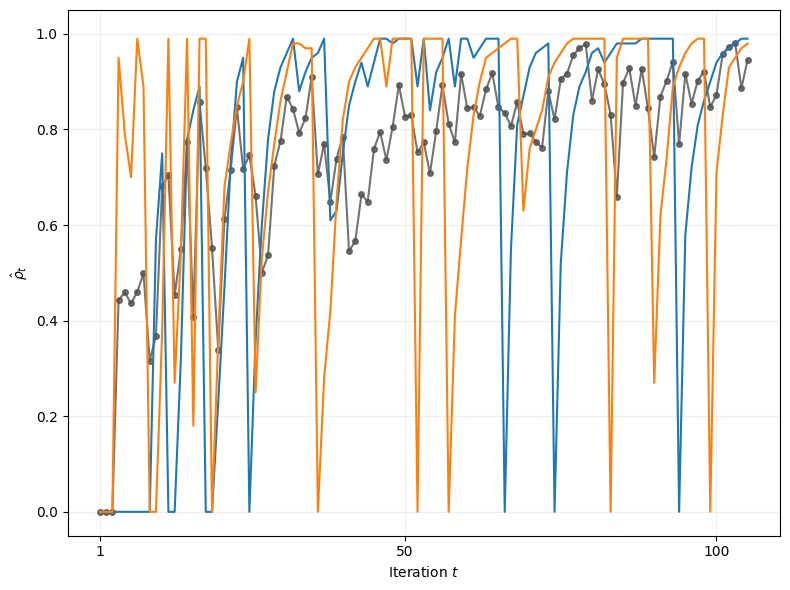

In [25]:
# Apply consistent styling
max_iter = 105  # Since you're using 1-105 on x-axis
colors = ['#505050']  # Using single color to match single dataset

fig, ax = plt.subplots(figsize=(8, 6))

y_mean = parameters[100].mean(axis=0).squeeze()
y_std = parameters[100].std(axis=0).squeeze()
lower_err = ((y_mean-y_std)>=0)*y_std + ((y_mean-y_std)<0)*(y_mean)
up_err = ((y_mean+y_std)<=1)*y_std + ((y_mean+y_std)>1)*(1-y_mean)
"""
plt.errorbar(x=np.arange(1, 106, 1), 
             y=y_mean, 
             yerr=[lower_err, up_err],
             color=colors[0],  # Using first gray color
             linewidth=1.5, 
             marker='o',
             markersize=4,
             capsize=3,
             alpha=0.8)  # Added slight transparency for elegance
"""
plt.plot(np.arange(1, 106), 
             y_mean, 
             color=colors[0],  # Using first gray color
             linewidth=1.5, 
             marker='o',
             markersize=4,
             alpha=0.8)

for run in parameters[100][:2]:
    plt.plot(np.arange(1, 106), 
             run.squeeze())

# Consistent formatting
plt.ylabel(r'$\hat{\rho}_t$')  # Update label as needed
plt.xlabel(r'Iteration $t$')  # Consistent with first plot

plt.ylim(-0.05, 1.05)

plt.xticks([1, 50, 100])  # Clean x-ticks every 10 iterations
plt.grid(alpha=0.2)
plt.tight_layout()
plt.savefig(DIR + "parameter_evolution.pdf",  # Update filename
           dpi=300, 
           bbox_inches='tight')